# 02. Sector de servicios y exposición al Tren Maya

Comparación del sector de servicios (núcleo) contra el resto de la economía, y dinamismo diferencial entre grupos de exposición al Tren Maya.

In [1]:
import sqlite3
import importlib.util
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

DB = Path("data/denue.db")
if not DB.exists():
    DB = Path("../data/denue.db")
DB = DB.resolve()


def cargar_etl():
    ruta = Path("etl/02_matching_demografia.py")
    if not ruta.exists():
        ruta = Path("../etl/02_matching_demografia.py")
    ruta = ruta.resolve()
    spec = importlib.util.spec_from_file_location("etl_matching", ruta)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


## 1. Carga de datos

In [2]:
if not DB.exists():
    mod = cargar_etl()
    mod.main()
    DB = mod.DB_PATH

con = sqlite3.connect(DB)
df23 = pd.read_sql("SELECT * FROM denue_2023", con)
df24 = pd.read_sql("SELECT * FROM denue_2024", con)
sobre = pd.read_sql("SELECT * FROM sobrevivientes", con)
nac = pd.read_sql("SELECT * FROM nacimientos", con)
mue = pd.read_sql("SELECT * FROM muertes", con)
con.close()

print(f"Unidades 2023: {len(df23):,}")
print(f"Unidades 2024: {len(df24):,}")
print(f"Sobrevivientes: {len(sobre):,}  |  Nacimientos: {len(nac):,}  |  Muertes: {len(mue):,}")


Unidades 2023: 41,783
Unidades 2024: 46,923
Sobrevivientes: 28,984  |  Nacimientos: 17,939  |  Muertes: 12,799


## 2. Grupo de exposición al Tren Maya (A/B/C)

Clasificación tomada de la sección 1.3 del `README.md` y codificada en `GRUPO_TREN_MAYA` de `etl/02_matching_demografia.py`:

- **A. Conectados y expuestos** (estaciones operativas desde dic-2023): Calkiní, Campeche, Champotón, Hecelchakán, Tenabo, Escárcega.
- **B. Conectados, exposición marginal** (estaciones del Tramo 7, abiertas hasta dic-2024, después del corte nov-2024): Carmen, Calakmul, Candelaria.
- **C. No conectados**: Hopelchén, Palizada, Seybaplaya, Dzitbalché.

Justificación: las estaciones se inauguraron por tramos en fechas distintas, por lo que la *exposición real* durante la ventana nov-2023 → nov-2024 difiere entre grupos.

In [3]:
def resumen_por_clave(col):
    u23 = df23.groupby(col).size()
    u24 = df24.groupby(col).size()
    s = sobre.groupby(col).size()
    n = nac.groupby(col).size()
    m = mue.groupby(col).size()
    r = pd.DataFrame({
        "U23": u23, "U24": u24, "Sobrevivientes": s,
        "Nacimientos": n, "Muertes": m,
    }).fillna(0).astype(int)
    r["tasa_supervivencia"] = (r["Sobrevivientes"] / r["U23"] * 100).round(1)
    r["tasa_natalidad"] = (r["Nacimientos"] / r["U24"] * 100).round(1)
    r["tasa_mortalidad"] = (r["Muertes"] / r["U23"] * 100).round(1)
    r["crecimiento_neto"] = ((r["U24"] - r["U23"]) / r["U23"] * 100).round(1)
    return r


## 3. Sector de servicios (núcleo) vs resto

In [4]:
# Dos grupos: núcleo vs resto
df23["grupo_serv"] = df23["sector_servicios"].where(df23["sector_servicios"] == "nucleo", "resto")
df24["grupo_serv"] = df24["sector_servicios"].where(df24["sector_servicios"] == "nucleo", "resto")
sobre["grupo_serv"] = sobre["sector_servicios"].where(sobre["sector_servicios"] == "nucleo", "resto")
nac["grupo_serv"] = nac["sector_servicios"].where(nac["sector_servicios"] == "nucleo", "resto")
mue["grupo_serv"] = mue["sector_servicios"].where(mue["sector_servicios"] == "nucleo", "resto")
resumen_por_clave("grupo_serv")

,U23,U24,Sobrevivientes,Nacimientos,Muertes,tasa_supervivencia,tasa_natalidad,tasa_mortalidad,crecimiento_neto
grupo_serv,,,,,,,,,
nucleo,5450,6452,3608,2844,1866,66.2,44.1,34.2,18.4
resto,36333,40471,25376,15095,10933,69.8,37.3,30.1,11.4


## 4. Desglose por nivel (núcleo / ampliado / excluido)

In [5]:
niv = resumen_por_clave("sector_servicios")
niv.reindex(["nucleo", "ampliado", "excluido", "resto"])

,U23,U24,Sobrevivientes,Nacimientos,Muertes,tasa_supervivencia,tasa_natalidad,tasa_mortalidad,crecimiento_neto
sector_servicios,,,,,,,,,
nucleo,5450,6452,3608,2844,1866,66.2,44.1,34.2,18.4
ampliado,358,356,235,121,122,65.6,34.0,34.1,-0.6
excluido,15,14,13,1,2,86.7,7.1,13.3,-6.7
resto,35960,40101,25128,14973,10809,69.9,37.3,30.1,11.5


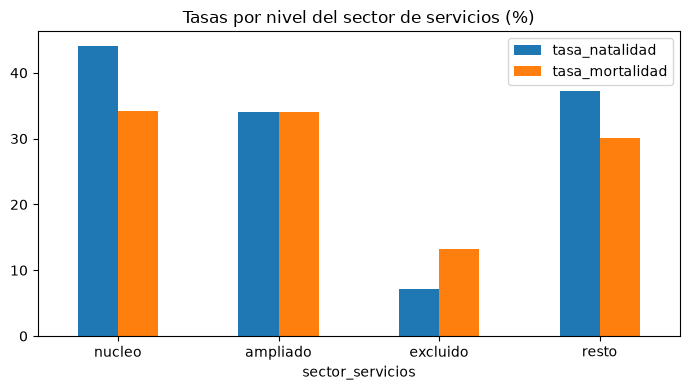

In [6]:
niv.reindex(["nucleo", "ampliado", "excluido", "resto"])[["tasa_natalidad", "tasa_mortalidad"]].plot.bar(figsize=(7, 4))
plt.title("Tasas por nivel del sector de servicios (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Desglose por subsector (núcleo + ampliado)

In [7]:
SUBSECTORES = {
    "7211": "Alojamiento",
    "7225": "Alimentos y bebidas",
    "5615": "Agencias de viajes",
    "7224": "Bares y centros nocturnos",
    "7132": "Parques recreativos",
    "7121": "Museos y sitios históricos",
    "4871": "Transporte (excluido)",
}

def tabla_subsector(df):
    d = df[df["sector_servicios"] != "resto"].copy()
    d["subsector"] = d["scian4"].map(SUBSECTORES)
    return d["subsector"].value_counts()

sub = pd.DataFrame({
    "Sobrevivientes": tabla_subsector(sobre),
    "Nacimientos": tabla_subsector(nac),
    "Muertes": tabla_subsector(mue),
}).fillna(0).astype(int)
sub

,Sobrevivientes,Nacimientos,Muertes
subsector,,,
Agencias de viajes,35,25,31
Alimentos y bebidas,3306,2746,1791
Alojamiento,267,73,44
Bares y centros nocturnos,122,64,77
Museos y sitios históricos,17,5,2
Parques recreativos,96,52,43
Transporte (excluido),13,1,2


## 6. Dinamismo por grupo de exposición al Tren Maya (A/B/C)

In [8]:
grupo = resumen_por_clave("grupo_tren")
grupo.reindex(["A", "B", "C"])

,U23,U24,Sobrevivientes,Nacimientos,Muertes,tasa_supervivencia,tasa_natalidad,tasa_mortalidad,crecimiento_neto
grupo_tren,,,,,,,,,
A,24875,26764,17160,9604,7692,69.0,35.9,30.9,7.6
B,13519,16228,9375,6853,4138,69.3,42.2,30.6,20.0
C,3389,3931,2449,1482,969,72.3,37.7,28.6,16.0


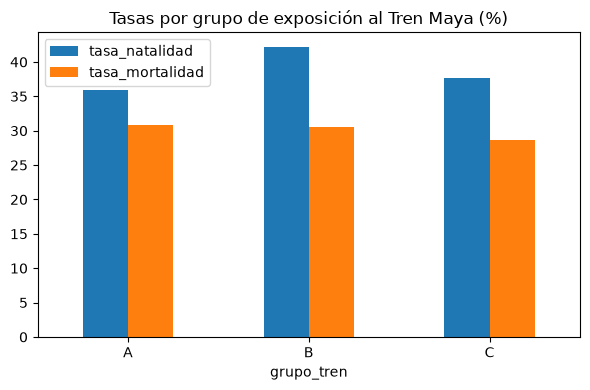

In [9]:
grupo.reindex(["A", "B", "C"])[["tasa_natalidad", "tasa_mortalidad"]].plot.bar(figsize=(6, 4))
plt.title("Tasas por grupo de exposición al Tren Maya (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Núcleo de servicios dentro de cada grupo

In [10]:
nucleo = sobre[sobre["sector_servicios"] == "nucleo"]
nac_nucleo = nac[nac["sector_servicios"] == "nucleo"]
mue_nucleo = mue[mue["sector_servicios"] == "nucleo"]
u23_nucleo = df23[df23["sector_servicios"] == "nucleo"]

r = pd.DataFrame({
    "U23": u23_nucleo.groupby("grupo_tren").size(),
    "Sobrevivientes": nucleo.groupby("grupo_tren").size(),
    "Nacimientos": nac_nucleo.groupby("grupo_tren").size(),
    "Muertes": mue_nucleo.groupby("grupo_tren").size(),
}).fillna(0).astype(int)
r["tasa_natalidad"] = (r["Nacimientos"] / r["U23"] * 100).round(1)
r["tasa_mortalidad"] = (r["Muertes"] / r["U23"] * 100).round(1)
r.reindex(["A", "B", "C"])

,U23,Sobrevivientes,Nacimientos,Muertes,tasa_natalidad,tasa_mortalidad
grupo_tren,,,,,,
A,3174,2040,1492,1128,47.0,35.5
B,1876,1299,1173,599,62.5,31.9
C,400,269,179,139,44.8,34.8


## 8. Índice de dinamismo del sector de servicios

`(N_núcleo / N_total) - (M_núcleo / M_total)`. Si es positivo, el núcleo de servicios gana más peso entre los nacimientos que entre las muertes.

In [11]:
n_total = len(nac)
m_total = len(mue)
n_nucleo = int((nac["sector_servicios"] == "nucleo").sum())
m_nucleo = int((mue["sector_servicios"] == "nucleo").sum())

idx = (n_nucleo / n_total) - (m_nucleo / m_total)
print(f"Índice de dinamismo del sector de servicios: {idx:+.4f}")

# Por grupo (núcleo de ese grupo vs totales globales)
indices = {}
for g in ["A", "B", "C"]:
    n_g = int(((nac["sector_servicios"] == "nucleo") & (nac["grupo_tren"] == g)).sum())
    m_g = int(((mue["sector_servicios"] == "nucleo") & (mue["grupo_tren"] == g)).sum())
    indices[g] = (n_g / n_total) - (m_g / m_total)
pd.Series(indices, name="indice_dinamismo").round(4)

Índice de dinamismo del sector de servicios: +0.0127


A   -0.0050
B    0.0186
C   -0.0009
Name: indice_dinamismo, dtype: float64

### Interpretación crítica

El índice positivo a nivel global (+0.0127) no debe leerse como desarrollo del sector: el Tren Maya **no ha dinamizado los negocios existentes**. El grupo A (municipios con el Tren Maya operativo desde dic-2023) tiene índice **negativo (−0.0050)**, mientras que el dinamismo se concentra en el grupo B (Carmen, Calakmul, Candelaria), cuyas estaciones abrieron apenas en dic-2024 — después del corte nov-2024 — y donde ese dinamismo puede reflejar mejor cobertura censal más que un efecto real.

En conjunto, el crecimiento observado es consistente con **reemplazo más que desarrollo**: nacen muchos negocios y mueren casi tantos, y el sector de servicios no muestra signos de fortalecimiento de los establecimientos existentes.


## 9. Exportar tablas clave a `data/processed/`

In [12]:
salida = Path("data/processed")
if not salida.exists():
    salida = Path("../data/processed")
salida.mkdir(parents=True, exist_ok=True)

niv.reindex(["nucleo", "ampliado", "excluido", "resto"]).to_csv(salida / "resumen_sector.csv", encoding="utf-8")
grupo.reindex(["A", "B", "C"]).to_csv(salida / "resumen_grupo_tren.csv", encoding="utf-8")
sub.to_csv(salida / "resumen_subsector.csv", encoding="utf-8")
r.reindex(["A", "B", "C"]).to_csv(salida / "resumen_nucleo_por_grupo.csv", encoding="utf-8")

print("Exportado a:", salida.resolve())

Exportado a: C:\Users\SEMAIG-437\Documents\Demografía de los negocios Campechanos\demografia-negocios-campeche\data\processed
